# Análise Financeira — ClearBank

Este notebook é autossuficiente: contém a leitura, validação, análise, exportação JSON e apresentação do relatório.

Antes de executar, crie manualmente `transacoes.csv` na mesma pasta, com as colunas `id,data,cliente_id,tipo,valor,descricao,categoria`. Use ao menos 15 linhas válidas em três meses, 5 inválidas e 2 valores acima de R$ 10.000,00.

In [1]:
import csv
import json
from datetime import date, datetime

LIMITE_SUSPEITO = 10000.00

def ler_transacoes(caminho):
    try:
        with open(caminho, encoding='utf-8', newline='') as arquivo:
            return list(csv.DictReader(arquivo))
    except FileNotFoundError:
        print(f'Arquivo não encontrado: {caminho}')
        return []

def validar_transacao(linha):
    try:
        identificador = int(linha.get('id', '').strip())
    except (ValueError, AttributeError):
        return None
    cliente_id = linha.get('cliente_id', '').strip()
    if not cliente_id:
        return None
    try:
        data = datetime.strptime(linha.get('data', '').strip(), '%Y-%m-%d')
    except (ValueError, AttributeError):
        return None
    tipo = linha.get('tipo', '').strip().lower()
    if tipo not in {'credito', 'debito'}:
        return None
    try:
        valor = float(linha.get('valor', '').strip())
    except (ValueError, AttributeError):
        return None
    if valor <= 0:
        return None
    return {'id': identificador, 'data': data, 'cliente_id': cliente_id, 'tipo': tipo, 'valor': valor, 'descricao': linha.get('descricao', '').strip(), 'categoria': linha.get('categoria', '').strip()}

def gerar_relatorio(transacoes, total_lido):
    por_mes = {}
    for transacao in transacoes:
        por_mes.setdefault(transacao['data'].strftime('%Y-%m'), []).append(transacao)
    resumo_mensal = {}
    for mes, itens in sorted(por_mes.items()):
        valores = [item['valor'] for item in itens]
        credito = sum(item['valor'] for item in itens if item['tipo'] == 'credito')
        debito = sum(item['valor'] for item in itens if item['tipo'] == 'debito')
        resumo_mensal[mes] = {'quantidade': len(itens), 'total_credito': credito, 'total_debito': debito, 'saldo': credito - debito, 'media': sum(valores) / len(valores), 'maior_valor': max(valores), 'menor_valor': min(valores)}
    datas = [item['data'] for item in transacoes]
    inicio, fim = (min(datas), max(datas)) if datas else (None, None)
    suspeitas = [{'id': item['id'], 'cliente_id': item['cliente_id'], 'data': item['data'].strftime('%Y-%m-%d'), 'valor': item['valor']} for item in transacoes if item['valor'] > LIMITE_SUSPEITO]
    return {'gerado_em': date.today().isoformat(), 'total_transacoes_validas': len(transacoes), 'total_transacoes_invalidas': total_lido - len(transacoes), 'periodo': {'inicio': inicio.strftime('%Y-%m-%d') if inicio else None, 'fim': fim.strftime('%Y-%m-%d') if fim else None, 'dias': (fim - inicio).days if inicio else 0}, 'resumo_mensal': resumo_mensal, 'transacoes_suspeitas': suspeitas}

def salvar_json(relatorio, caminho='relatorio.json'):
    with open(caminho, 'w', encoding='utf-8') as arquivo:
        json.dump(relatorio, arquivo, ensure_ascii=False, indent=2)

def formatar_moeda(valor):
    return f'R$ {valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

def exibir_relatorio(relatorio):
    print('===== RESUMO DA LIMPEZA =====')
    print(f"Total de linhas lidas: {relatorio['total_transacoes_validas'] + relatorio['total_transacoes_invalidas']}")
    print(f"Linhas válidas: {relatorio['total_transacoes_validas']}")
    print(f"Linhas inválidas: {relatorio['total_transacoes_invalidas']}")
    periodo = relatorio['periodo']
    print('\n===== PERÍODO ANALISADO =====')
    print(f"{periodo['inicio']} → {periodo['fim']} ({periodo['dias']} dias)")
    print('\n===== RELATÓRIO MENSAL =====')
    for mes, metricas in relatorio['resumo_mensal'].items():
        print(f'Mês: {mes}')
        print(f"  Transações: {metricas['quantidade']}")
        print(f"  Total crédito: {formatar_moeda(metricas['total_credito'])}")
        print(f"  Total débito:  {formatar_moeda(metricas['total_debito'])}")
        print(f"  Saldo:         {formatar_moeda(metricas['saldo'])}")
        print(f"  Média:         {formatar_moeda(metricas['media'])}")
        print(f"  Maior valor:   {formatar_moeda(metricas['maior_valor'])}")
        print(f"  Menor valor:   {formatar_moeda(metricas['menor_valor'])}")
    print('\n===== TRANSAÇÕES SUSPEITAS =====')
    if not relatorio['transacoes_suspeitas']:
        print('Nenhuma transação suspeita encontrada.')
    for transacao in relatorio['transacoes_suspeitas']:
        print(f"ID: {transacao['id']} | Cliente: {transacao['cliente_id']} | Data: {transacao['data']} | Valor: {formatar_moeda(transacao['valor'])}")

def executar_analise(caminho_csv='transacoes.csv'):
    linhas = ler_transacoes(caminho_csv)
    transacoes = [transacao for linha in linhas if (transacao := validar_transacao(linha))]
    relatorio = gerar_relatorio(transacoes, len(linhas))
    salvar_json(relatorio)
    exibir_relatorio(relatorio)
    return relatorio

print('Funções carregadas com sucesso.')

Funções carregadas com sucesso.


## Testes rápidos

Os testes abaixo validam uma transação válida, o descarte de um valor inválido e a formatação monetária.

In [2]:
amostra_valida = {'id': '99', 'data': '2026-01-05', 'cliente_id': 'CLI999', 'tipo': 'credito', 'valor': '100.50', 'descricao': 'Teste', 'categoria': 'teste'}
amostra_invalida = {**amostra_valida, 'valor': 'abc'}

assert validar_transacao(amostra_valida)['valor'] == 100.50
assert validar_transacao(amostra_invalida) is None
assert formatar_moeda(1234.5) == 'R$ 1.234,50'
print('3 testes rápidos aprovados.')

3 testes rápidos aprovados.


## Execução principal

A célula executa todo o fluxo e gera `relatorio.json`.

In [3]:
relatorio = executar_analise()
relatorio

===== RESUMO DA LIMPEZA =====
Total de linhas lidas: 20
Linhas válidas: 15
Linhas inválidas: 5

===== PERÍODO ANALISADO =====
2026-01-05 → 2026-03-30 (84 dias)

===== RELATÓRIO MENSAL =====
Mês: 2026-01
  Transações: 4
  Total crédito: R$ 3.500,00
  Total débito:  R$ 516,40
  Saldo:         R$ 2.983,60
  Média:         R$ 1.004,10
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 85,90
Mês: 2026-02
  Transações: 5
  Total crédito: R$ 19.200,00
  Total débito:  R$ 980,65
  Saldo:         R$ 18.219,35
  Média:         R$ 4.036,13
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 99,90
Mês: 2026-03
  Transações: 6
  Total crédito: R$ 16.350,00
  Total débito:  R$ 1.890,65
  Saldo:         R$ 14.459,35
  Média:         R$ 3.040,11
  Maior valor:   R$ 12.050,00
  Menor valor:   R$ 210,00

===== TRANSAÇÕES SUSPEITAS =====
ID: 7 | Cliente: CLI004 | Data: 2026-02-14 | Valor: R$ 15.000,00
ID: 12 | Cliente: CLI003 | Data: 2026-03-12 | Valor: R$ 12.050,00


{'gerado_em': '2026-07-14',
 'total_transacoes_validas': 15,
 'total_transacoes_invalidas': 5,
 'periodo': {'inicio': '2026-01-05', 'fim': '2026-03-30', 'dias': 84},
 'resumo_mensal': {'2026-01': {'quantidade': 4,
   'total_credito': 3500.0,
   'total_debito': 516.4,
   'saldo': 2983.6,
   'media': 1004.1,
   'maior_valor': 3500.0,
   'menor_valor': 85.9},
  '2026-02': {'quantidade': 5,
   'total_credito': 19200.0,
   'total_debito': 980.65,
   'saldo': 18219.35,
   'media': 4036.13,
   'maior_valor': 15000.0,
   'menor_valor': 99.9},
  '2026-03': {'quantidade': 6,
   'total_credito': 16350.0,
   'total_debito': 1890.65,
   'saldo': 14459.35,
   'media': 3040.1083333333336,
   'maior_valor': 12050.0,
   'menor_valor': 210.0}},
 'transacoes_suspeitas': [{'id': 7,
   'cliente_id': 'CLI004',
   'data': '2026-02-14',
   'valor': 15000.0},
  {'id': 12, 'cliente_id': 'CLI003', 'data': '2026-03-12', 'valor': 12050.0}]}

## Extra opcional — gráfico

Esta célula gera `grafico.png` com o saldo mensal.

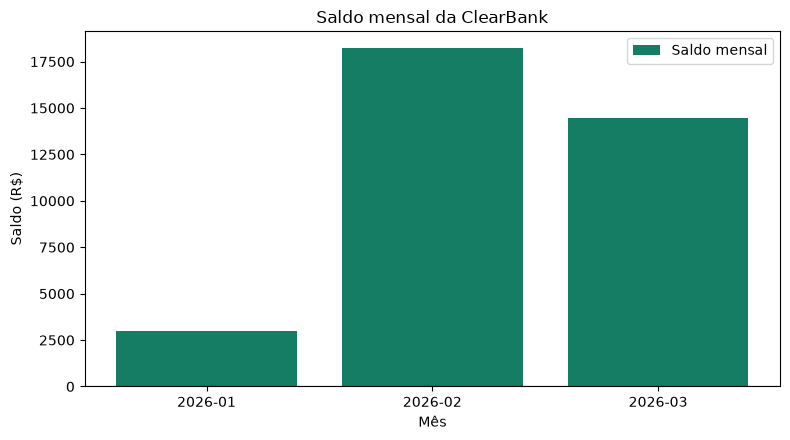

In [4]:
import matplotlib.pyplot as plt

meses = list(relatorio['resumo_mensal'])
saldos = [relatorio['resumo_mensal'][mes]['saldo'] for mes in meses]
figura, eixo = plt.subplots(figsize=(8, 4.5))
eixo.bar(meses, saldos, color='#147d64', label='Saldo mensal')
eixo.set_title('Saldo mensal da ClearBank')
eixo.set_xlabel('Mês')
eixo.set_ylabel('Saldo (R$)')
eixo.axhline(0, color='#333333', linewidth=0.8)
eixo.legend()
figura.tight_layout()
figura.savefig('grafico.png', dpi=150)
plt.show()